# [LELEC2870] - Machine Learning
## Part 3 — Integration of Image Data



In this notebook, we integrate heart scan images into the predictive pipeline. We extract features from images using a CNN and combine them with tabular data for prediction.


In [137]:

# Standard libraries
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Image processing
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, random_split

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')


### 2.1 Load Tabular and Image Data


In [138]:
data_path = "../data/data_labeled"
train_csv = os.path.join(data_path, "X_train.csv")
y_train_csv = os.path.join(data_path, "y_train.csv")
img_dir = os.path.join(data_path, "Img_train")
X_train_full = pd.read_csv(train_csv)

if 'img_filename' in X_train_full.columns:
    images = X_train_full['img_filename'].values
    img_col = 'img_filename'
else:
    images = X_train_full.iloc[:, -1].values
    img_col = X_train_full.columns[-1]

print(f"Images chargées: {len(images)}")


y_train_df = pd.read_csv(y_train_csv, header=None)
y = y_train_df.values.flatten()
print(f"Targets chargées: {y.shape[0]}")

tabular_cols = [col for col in X_train_full.columns if col != img_col]
X_tabular = X_train_full[tabular_cols].select_dtypes(include=[np.number])
X_categorical = X_train_full[tabular_cols].select_dtypes(exclude=[np.number])

print(f"Features numériques: {X_tabular.shape[1]}, Features catégorielles: {X_categorical.shape[1]}")

print(f"Nombre d'échantillons: {len(images)}")

Images chargées: 1000
Targets chargées: 1000
Features numériques: 9, Features catégorielles: 4
Nombre d'échantillons: 1000


### 2.2 Define Custom Dataset


In [139]:

class HeartScanDataset(Dataset):
    """Dataset pour les scans cardiaques des Smurfs"""
    
    def __init__(self, img_filenames, img_dir, targets=None, transform=None):
        self.img_filenames = img_filenames
        self.img_dir = img_dir
        self.targets = targets
        
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Grayscale(num_output_channels=1),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.5], std=[0.5])  # [-1, 1]
            ])
        else:
            self.transform = transform
    
    def __len__(self):
        return len(self.img_filenames)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_filenames[idx])
        
        try:
            img = Image.open(img_path)
            img = self.transform(img)
            
            if self.targets is not None:
                target = torch.tensor(self.targets[idx], dtype=torch.float32)
                return img, target
            return img
        except Exception as e:
            print(f" Erreur image {img_path}: {e}")
            dummy_img = torch.zeros(1, 48, 48)
            if self.targets is not None:
                return dummy_img, torch.tensor(0.0)
            return dummy_img

# Création du dataset complet
dataset_full = HeartScanDataset(images, img_dir, y)
print(f"Dataset créé: {len(dataset_full)} échantillons")

# Test de chargement
sample_img, sample_label = dataset_full[0]
print(f"Image shape: {sample_img.shape}")
print(f"Label: {sample_label.item():.6f}")

# Train/Val split (80/20)
train_size = int(0.8 * len(dataset_full))
val_size = len(dataset_full) - train_size

train_dataset, val_dataset = random_split(
    dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {train_size} | Val: {val_size}")

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Dataset créé: 1000 échantillons
Image shape: torch.Size([1, 48, 48])
Label: 0.060000
Train: 800 | Val: 200
Train batches: 25 | Val batches: 7


### Architecture CNN

In [140]:


class SimpleCNN(nn.Module):
    """
    CNN simple pour extraire des features des scans cardiaques.
    """
    
    def __init__(self, n_features=8):
        super(SimpleCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(16 * 12 * 12, n_features)
        self.fc2 = nn.Linear(n_features, 1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        # Conv + Pool 1
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        
        # Conv + Pool 2
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)  

        features = self.relu(self.fc1(x))
        features = self.dropout(features)

        output = self.fc2(features)
        
        return output, features

n_features = 8
cnn = SimpleCNN(n_features=n_features)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cnn = cnn.to(device)

print(f"CNN créé avec {n_features} features extraites")
print(f"Device: {device}")

# Nombre de paramètres
total_params = sum(p.numel() for p in cnn.parameters())
trainable_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f"Paramètres: {trainable_params:,} trainable / {total_params:,} total")

CNN créé avec 8 features extraites
Device: cpu
Paramètres: 19,697 trainable / 19,697 total


### Training of the CNN

Début de l'entraînement: 20 epochs, batch_size=32, lr=0.0005

Epoch  1/20 | Train Loss: 0.014427 | Val Loss: 0.007081 | Best Val: 0.007081
Epoch  5/20 | Train Loss: 0.006997 | Val Loss: 0.004863 | Best Val: 0.004863
Epoch 10/20 | Train Loss: 0.005388 | Val Loss: 0.004058 | Best Val: 0.004058
Epoch 15/20 | Train Loss: 0.004292 | Val Loss: 0.004047 | Best Val: 0.003952
Epoch 20/20 | Train Loss: 0.003662 | Val Loss: 0.004076 | Best Val: 0.003952
 Meilleure val loss: 0.003952
 Meilleur modèle rechargé


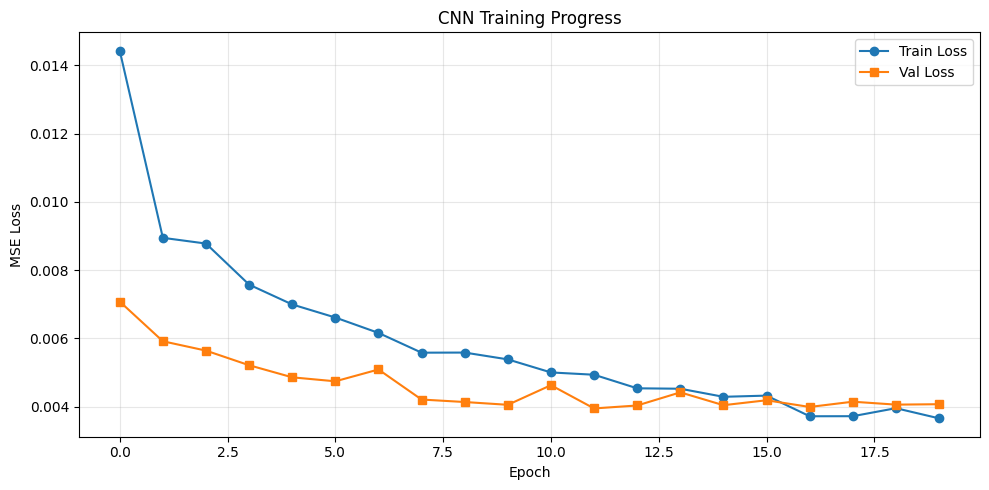

In [141]:

criterion = nn.MSELoss()
optimizer = optim.Adam(cnn.parameters(), lr=0.0005)

# Paramètres
n_epochs = 20
best_val_loss = float('inf')

# Historique
train_losses = []
val_losses = []

print(f"Début de l'entraînement: {n_epochs} epochs, batch_size={batch_size}, lr=0.0005\n")

for epoch in range(n_epochs):
    cnn.train()
    train_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs, _ = cnn(inputs)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)
    cnn.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs, _ = cnn(inputs)
            loss = criterion(outputs.squeeze(), labels)
            val_loss += loss.item() * inputs.size(0)
    
    val_loss /= len(val_dataset)
    val_losses.append(val_loss)
    
    # on save le meilleur
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(cnn.state_dict(), 'best_cnn_model.pth')
    
    # Affichage
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{n_epochs} | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"Best Val: {best_val_loss:.6f}")

print(f" Meilleure val loss: {best_val_loss:.6f}")

# load le best
cnn.load_state_dict(torch.load('best_cnn_model.pth'))
print(f" Meilleur modèle rechargé")

# plot
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('CNN Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150)
plt.show()

### Extraction of CNN features

In [142]:

# Dataset complet
full_dataset = HeartScanDataset(images, img_dir, y)
full_loader = DataLoader(full_dataset, batch_size=50, shuffle=False, num_workers=0)

# Extraction
all_features = []
all_predictions = []

cnn.eval()
with torch.no_grad():
    for inputs, _ in full_loader:
        inputs = inputs.to(device)
        outputs, features = cnn(inputs)
        all_features.append(features.cpu().numpy())
        all_predictions.append(outputs.squeeze().cpu().numpy())

# tout
image_features = np.vstack(all_features)
cnn_predictions = np.concatenate(all_predictions)

print(f"Features extraites: {image_features.shape}")
print(f"Prédictions CNN: {cnn_predictions.shape}")

# Cnn seul
cnn_rmse = np.sqrt(mean_squared_error(y, cnn_predictions))
cnn_r2 = r2_score(y, cnn_predictions)
cnn_mae = mean_absolute_error(y, cnn_predictions)

print(f"\n CNN seul")
print(f"  RMSE: {cnn_rmse:.6f}")
print(f"  R²:   {cnn_r2:.4f}")
print(f"  MAE:  {cnn_mae:.6f}")

Features extraites: (1000, 8)
Prédictions CNN: (1000,)

 CNN seul
  RMSE: 0.056935
  R²:   0.5035
  MAE:  0.039063


### Combination with tabular data

In [143]:

X_combined = np.hstack([X_tabular.values, image_features])
print(f"X_combined shape: {X_combined.shape}")
print(f"  - Features tabulaires: {X_tabular.shape[1]}")
print(f"  - Features images: {image_features.shape[1]}")
print(f"  - Total: {X_combined.shape[1]}")

X_combined shape: (1000, 17)
  - Features tabulaires: 9
  - Features images: 8
  - Total: 17


### Final model and evaluations

Train: 800 | Test: 200

 Entraînement RandomForest
  Train - RMSE: 0.016745 | R²: 0.9594
  Test  - RMSE: 0.033040 | R²: 0.7813

 Comparaison avec CNN seul:
  CNN seul  - RMSE: 0.056935
  Combiné   - RMSE: 0.033040
  Amélioration: 41.97%


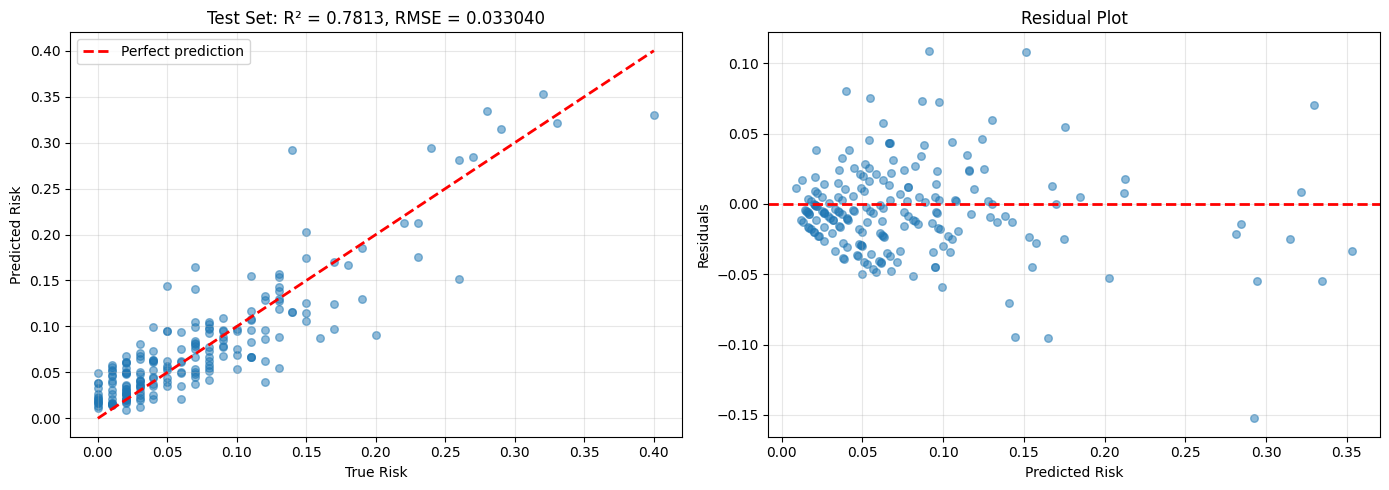

1. CNN entraîné: 20 epochs, 8 features extraites
2. Performance CNN seul: RMSE = 0.056935
3. Features combinées: 17 dimensions
4. Modèle final (RF): RMSE = 0.033040, R² = 0.7813
5. Amélioration: 41.97%


In [144]:


from sklearn.preprocessing import StandardScaler
# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement RandomForest
print("\n Entraînement RandomForest")
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

# Predict
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"  Train - RMSE: {train_rmse:.6f} | R²: {train_r2:.4f}")
print(f"  Test  - RMSE: {test_rmse:.6f} | R²: {test_r2:.4f}")

# Comparaison
print(f"\n Comparaison avec CNN seul:")
print(f"  CNN seul  - RMSE: {cnn_rmse:.6f}")
print(f"  Combiné   - RMSE: {test_rmse:.6f}")
print(f"  Amélioration: {((cnn_rmse - test_rmse) / cnn_rmse * 100):.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predictions vs true
axes[0].scatter(y_test, y_test_pred, alpha=0.5, s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('True Risk')
axes[0].set_ylabel('Predicted Risk')
axes[0].set_title(f'Test Set: R² = {test_r2:.4f}, RMSE = {test_rmse:.6f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: résiduts
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.5, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Risk')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('part3_final_results.png', dpi=150)
plt.show()

#résumé
print(f"1. CNN entraîné: {n_epochs} epochs, {n_features} features extraites")
print(f"2. Performance CNN seul: RMSE = {cnn_rmse:.6f}")
print(f"3. Features combinées: {X_combined.shape[1]} dimensions")
print(f"4. Modèle final (RF): RMSE = {test_rmse:.6f}, R² = {test_r2:.4f}")
print(f"5. Amélioration: {((cnn_rmse - test_rmse) / cnn_rmse * 100):.2f}%")


### sauvegarde du modèle et des prédictions


In [145]:


unlabeled_path = "../data/data_unlabeled"
X_unlabeled_csv = os.path.join(unlabeled_path, "X.csv")
img_unlabeled_dir = os.path.join(unlabeled_path, "Img")

X_unlabeled = pd.read_csv(X_unlabeled_csv)

if 'img_filename' in X_unlabeled.columns:
    images_unlabeled = X_unlabeled['img_filename'].values
    img_col = 'img_filename'
else:
    images_unlabeled = X_unlabeled.iloc[:, -1].values
    img_col = X_unlabeled.columns[-1]

tabular_cols = [col for col in X_unlabeled.columns if col != img_col]
X_unlabeled_tabular = X_unlabeled[tabular_cols].select_dtypes(include=[np.number])


# Dataset sans labels
unlabeled_dataset = HeartScanDataset(images_unlabeled, img_unlabeled_dir, targets=None)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=50, shuffle=False, num_workers=0)

all_unlabeled_features = []

cnn.eval()
with torch.no_grad():
    for inputs in unlabeled_loader:
        inputs = inputs.to(device)
        _, features = cnn(inputs)
        all_unlabeled_features.append(features.cpu().numpy())

image_features_unlabeled = np.vstack(all_unlabeled_features)

X_unlabeled_combined = np.hstack([X_unlabeled_tabular.values, image_features_unlabeled])

print(f"Features combinées: {X_unlabeled_combined.shape}")
print(f"  - Features tabulaires: {X_unlabeled_tabular.shape[1]}")
print(f"  - Features CNN: {image_features_unlabeled.shape[1]}")
print(f"  - Total: {X_unlabeled_combined.shape[1]}")


X_unlabeled_scaled = scaler.transform(X_unlabeled_combined)
# avec randomforest
predictions = rf_model.predict(X_unlabeled_scaled)

# prédiction >0  ??!!
predictions = np.maximum(0, predictions)

print(f"  Min:    {predictions.min():.6f}")
print(f"  Max:    {predictions.max():.6f}")
print(f"  Mean:   {predictions.mean():.6f}")
print(f"  Median: {np.median(predictions):.6f}")
print(f"  Std:    {predictions.std():.6f}")



final_predictions_df = pd.DataFrame(predictions)

output_file = '../results/predictions/y_pred_part3.csv'
final_predictions_df.to_csv(output_file, index=False, header=False)


with open(output_file, 'r') as f:
    first_lines = [f.readline().strip() for _ in range(5)]

print("✓ Premières lignes du fichier:")
for i, line in enumerate(first_lines, 1):
    print(f"  {i}. {line}")

# Vérification du nombre de lignes
with open(output_file, 'r') as f:
    num_lines = sum(1 for _ in f)
import json
from datetime import datetime

model_info = {
    'model_name': 'RandomForest + CNN Features',
    'model_type': 'non-linear + deep learning',
    'architecture': {
        'cnn': {
            'type': 'SimpleCNN',
            'n_features': n_features,
            'n_epochs': n_epochs,
            'best_val_loss': best_val_loss
        },
        'tabular_model': 'RandomForest',
        'n_estimators': 200,
        'max_depth': 15
    },
    'performance': {
        'cnn_alone_rmse': float(cnn_rmse),
        'cnn_alone_r2': float(cnn_r2),
        'combined_rmse_train': float(train_rmse),
        'combined_rmse_test': float(test_rmse),
        'combined_r2_train': float(train_r2),
        'combined_r2_test': float(test_r2),
        'improvement_vs_cnn_alone': f"{((cnn_rmse - test_rmse) / cnn_rmse * 100):.2f}%"
    },
    'features': {
        'tabular_features': int(X_tabular.shape[1]),
        'cnn_features': int(image_features.shape[1]),
        'total_features': int(X_combined.shape[1])
    },
    'predictions': {
        'n_samples': int(len(predictions)),
        'min': float(predictions.min()),
        'max': float(predictions.max()),
        'mean': float(predictions.mean()),
        'std': float(predictions.std())
    },
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

info_path = '../results/models/part3_model_info.json'
with open(info_path, 'w') as f:
    json.dump(model_info, f, indent=4)


import joblib

# Sauvegarder le CNN
torch.save(cnn.state_dict(), '../results/models/part3_cnn_model.pth')

# Sauvegarder le RandomForest
joblib.dump(rf_model, '../results/models/part3_rf_model.pkl')


# Sauvegarder le scaler
joblib.dump(scaler, '../results/models/part3_scaler.pkl')




print(f"RMSE Test: {test_rmse:.6f}")
print(f"R² Test: {test_r2:.4f}")
print(f"Amélioration vs CNN seul: {((cnn_rmse - test_rmse) / cnn_rmse * 100):.2f}%")



Features combinées: (500, 17)
  - Features tabulaires: 9
  - Features CNN: 8
  - Total: 17
  Min:    0.007963
  Max:    0.376314
  Mean:   0.084428
  Median: 0.067981
  Std:    0.063280
✓ Premières lignes du fichier:
  1. 0.05368498256373254
  2. 0.0693913943001443
  3. 0.020868802297280564
  4. 0.07156619810744808
  5. 0.015019802083590883
RMSE Test: 0.033040
R² Test: 0.7813
Amélioration vs CNN seul: 41.97%
